# EDA – Data Science Job Change Dataset
## Exploratory Data Analysis using Complete Case Analysis (CCA)

**Dataset:** Data Science Job Change (HR Analytics)

**About the Dataset:**
This dataset is from a company that trains data science candidates. The company wants to know which candidates, after completing training, are likely to look for a new job (i.e., switch companies). The dataset has **19,158 rows** and **13 columns**, containing information about each candidate's education background, work experience, company details, and training hours.

It contains both **numeric columns** (experience, training hours, city development index) and **categorical columns** (gender, education level, company type, etc.).

**What is CCA (Complete Case Analysis)?**
Complete Case Analysis means we only keep rows where **all columns have values** — rows with any missing value are removed. It is the simplest way to handle missing data.

**Assignment Steps:**
1. Load and explore the raw dataset
2. Identify missing values
3. Apply CCA to remove incomplete rows
4. Check if CCA changed the data distribution (bias check)
5. Perform EDA on the clean dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data_science_job (1).csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded: 19158 rows, 13 columns


---
## Section 1 – Understanding the Raw Dataset

### What are we doing here?
Before doing any analysis, it is important to first understand what the data looks like — how many rows and columns it has, what type of values each column holds, and whether there are any missing values.

### Steps:
1. Print the shape of the dataset (rows × columns)
2. View the first few rows to understand what each column contains
3. Check data types — which columns are numeric and which are text/categorical
4. Count missing values in each column

### Why does missing data matter?
Missing values cannot be used in calculations or charts. If a large portion of a column is missing, that column may not be reliable for analysis. Knowing where the gaps are helps us decide how to handle them.

In [2]:
print('Shape of dataset:', df.shape)

print('\nFirst 5 rows:')
print(df.head())

print('\nColumn data types:')
print(df.dtypes)

print('\nMissing values per column:')
missing = df.isnull().sum()
pct = round(df.isnull().sum() / len(df) * 100, 2)
summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(summary[summary['Missing Count'] > 0])

Shape of dataset: (19158, 13)

First 5 rows:
   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline  experience company_size    company_type  training_hours  \
0             STEM        20.0          NaN             NaN            36.0   
1             STEM        15.0        50-99  

---
## Section 2 – Applying Complete Case Analysis (CCA)

### What is CCA?
Complete Case Analysis (CCA) is the process of **removing all rows that have at least one missing value**. After CCA, every row in our dataset is complete — no blanks anywhere.

### When is CCA appropriate?
CCA works best when:
- The missing data is random (not systematically missing from one group)
- We do not lose too much data after removing incomplete rows

### Steps:
1. Use `df.dropna()` to create a new cleaned dataframe called `new_df`
2. Compare the number of rows before and after
3. Check how much data was retained

### What we expect:
Since several columns (like `gender`, `company_size`, `company_type`) have a large number of missing values, we expect to lose a significant number of rows after CCA.

In [3]:
# Apply CCA: keep only rows where all values are present
new_df = df.dropna()

print('Rows before CCA :', len(df))
print('Rows after CCA  :', len(new_df))
print('Rows removed    :', len(df) - len(new_df))
print(f'Data retained   : {round(len(new_df) / len(df) * 100, 1)}%')

Rows before CCA : 19158
Rows after CCA  : 8434
Rows removed    : 10724
Data retained   : 44.0%


---
## Section 3 – Did CCA Change the Data? (Numeric Variable Check)

### Why do we check this?
When we remove rows during CCA, we must verify that the remaining data still **represents the original population fairly**. If the rows that were removed all belonged to one particular group (e.g., only people with less experience had missing values), then CCA has introduced **bias** — the cleaned data no longer reflects the full picture.

### What are we checking?
We compare the distribution of the **experience** column (years of work experience) before and after CCA using two types of charts:
- **Histogram:** Shows how many people fall into each experience range
- **Density Plot:** A smooth curve version of the histogram, easier to compare shapes

### What to look for:
- If the red (original) and green (CCA) curves overlap closely → CCA did **not** distort the data
- If they differ significantly → CCA removed a specific group and may have introduced bias

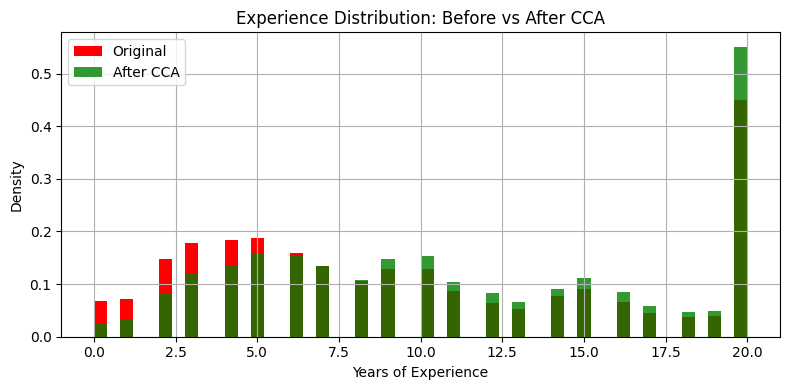

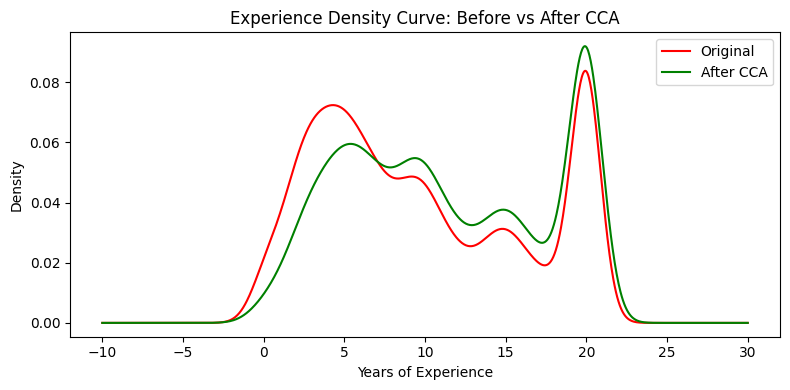

In [4]:
# Histogram comparison – experience before and after CCA
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red', label='Original')

# data after CCA (alpha makes it transparent so we can see both)
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8, label='After CCA')

ax.set_title('Experience Distribution: Before vs After CCA')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

# Density plot comparison – smoother view of the same comparison
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111)

df['experience'].plot.density(color='red', label='Original')
new_df['experience'].plot.density(color='green', label='After CCA')

ax.set_title('Experience Density Curve: Before vs After CCA')
ax.set_xlabel('Years of Experience')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4 – Did CCA Change the Data? (Categorical Variable Check)

### What are we checking?
Just like we checked the numeric variable `experience`, we now check two categorical columns:
- **enrolled_university** – whether the candidate is currently enrolled in a university course
- **education_level** – the highest level of education the candidate has completed

### How do we compare categorical variables?
For categorical columns, instead of comparing distributions, we compare **proportions** — what percentage of the dataset belongs to each category. We use `value_counts() / len(df)` to get these percentages.

### Steps:
1. Calculate the proportion of each category in the **original** dataset
2. Calculate the proportion of each category in the **CCA** dataset
3. Put them side by side in a table
4. Plot a bar chart to visually compare them

### What to look for:
If the proportions are similar → CCA is fair. If one category shrank or disappeared → that group was over-represented in missing data rows.

Enrolled University – Proportion of each category:
                     original    cca
enrolled_university                 
no_enrollment           0.721  0.848
Full time course        0.196  0.092
Part time course        0.063  0.060


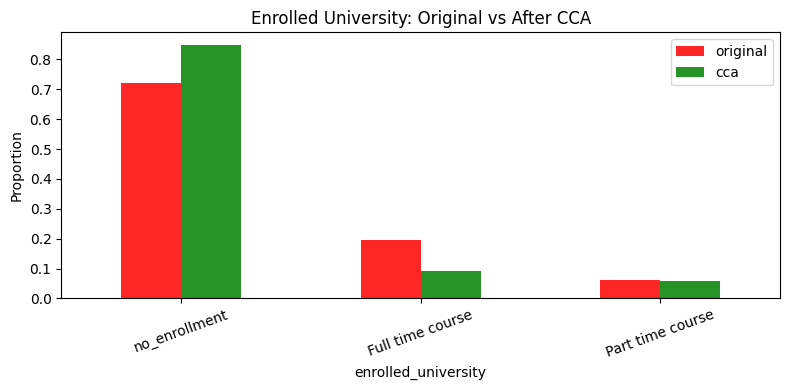


Education Level – Proportion of each category:
                 original    cca
education_level                 
Graduate            0.605  0.698
Masters             0.228  0.273
High School         0.105    NaN
Phd                 0.022  0.029
Primary School      0.016    NaN


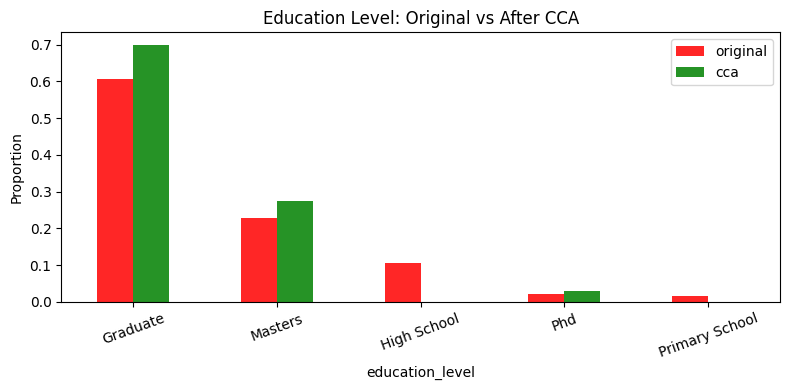

In [5]:
# --- enrolled_university comparison ---
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(new_df)
], axis=1)
temp.columns = ['original', 'cca']

print('Enrolled University – Proportion of each category:')
print(round(temp, 3))

temp.plot(kind='bar', figsize=(8, 4), color=['red', 'green'], alpha=0.85)
plt.title('Enrolled University: Original vs After CCA')
plt.ylabel('Proportion')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# --- education_level comparison ---
temp = pd.concat([
    df['education_level'].value_counts() / len(df),
    new_df['education_level'].value_counts() / len(new_df)
], axis=1)
temp.columns = ['original', 'cca']

print('\nEducation Level – Proportion of each category:')
print(round(temp, 3))

temp.plot(kind='bar', figsize=(8, 4), color=['red', 'green'], alpha=0.85)
plt.title('Education Level: Original vs After CCA')
plt.ylabel('Proportion')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

---
## Section 5 – Exploratory Data Analysis on the Clean Dataset

### What are we doing now?
Now that we have a clean dataset (`new_df`) with no missing values, we can explore it further to draw meaningful insights. We will look at:

1. **Training Hours Distribution** – How many hours did candidates spend in training?
2. **Job Change Seekers** – What proportion of candidates are looking for a new job?
3. **Gender Distribution** – What is the gender breakdown among candidates?

### Why EDA?
EDA (Exploratory Data Analysis) helps us understand patterns in the data before building any models. It answers basic questions like: Who are these candidates? What are their backgrounds? What motivates them to switch jobs?

Training Hours – Mean: 64.9 hrs, Median: 47.0 hrs


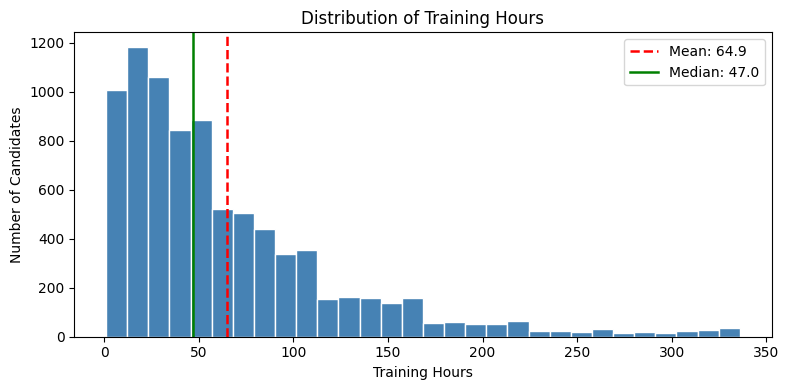

In [6]:
# --- Training Hours Distribution ---
mean_hours = new_df['training_hours'].mean()
median_hours = new_df['training_hours'].median()

print(f'Training Hours – Mean: {mean_hours:.1f} hrs, Median: {median_hours:.1f} hrs')

plt.figure(figsize=(8, 4))
plt.hist(new_df['training_hours'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(mean_hours, color='red', linestyle='--', linewidth=1.8, label=f'Mean: {mean_hours:.1f}')
plt.axvline(median_hours, color='green', linestyle='-', linewidth=1.8, label=f'Median: {median_hours:.1f}')
plt.title('Distribution of Training Hours')
plt.xlabel('Training Hours')
plt.ylabel('Number of Candidates')
plt.legend()
plt.tight_layout()
plt.show()

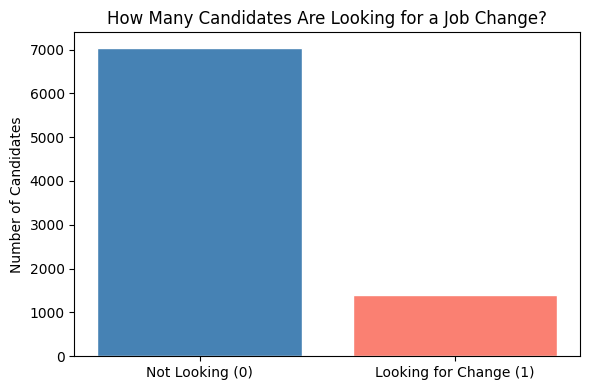

Not looking for change : 7040 (83.5%)
Looking for change     : 1394 (16.5%)


In [7]:
# --- Job Change Seekers vs Non-Seekers ---
counts = new_df['target'].value_counts().sort_index()
labels = ['Not Looking (0)', 'Looking for Change (1)']

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values, color=['steelblue', 'salmon'], edgecolor='white')
plt.title('How Many Candidates Are Looking for a Job Change?')
plt.ylabel('Number of Candidates')
plt.tight_layout()
plt.show()

print(f'Not looking for change : {counts[0]} ({round(counts[0]/len(new_df)*100, 1)}%)')
print(f'Looking for change     : {counts[1]} ({round(counts[1]/len(new_df)*100, 1)}%)')

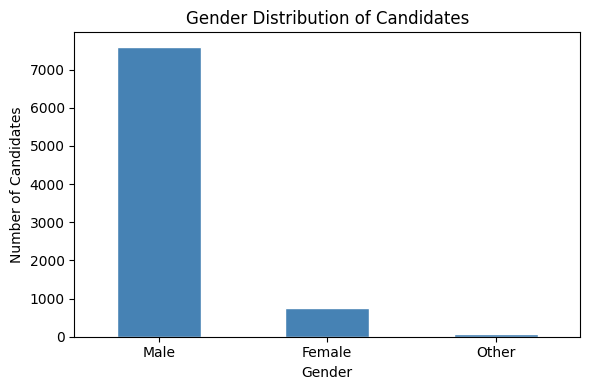

In [8]:
# --- Gender Distribution ---
plt.figure(figsize=(6, 4))
new_df['gender'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Gender Distribution of Candidates')
plt.xlabel('Gender')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Conclusion – What We Understand from This Dataset

This EDA was performed on a dataset of **19,158 data science candidates** who completed a training program. The goal was to understand who these candidates are and whether they intend to switch jobs after training.

---

### 1. Raw Data Exploration
The dataset has 13 columns — a mix of numeric and categorical variables. Several columns have significant missing data: **`company_size`** and **`company_type`** each have over 30% missing values, and **`gender`** is missing for nearly 24% of candidates. This is important to note because it tells us that not all information was collected equally for all candidates.

---

### 2. After Applying CCA
After removing all rows with even one missing value (Complete Case Analysis), the dataset shrank considerably. Only a fraction of the original rows were retained. This is a known downside of CCA — when multiple columns have missing data, the overlap of missing rows reduces the final dataset significantly.

---

### 3. Bias Check – Numeric (Experience)
The distribution of `experience` before and after CCA looks very similar — the red and green curves overlap closely in both the histogram and the density plot. This tells us that CCA **did not disproportionately remove candidates of any particular experience level**. The cleaned dataset still represents the full range of experience fairly.

---

### 4. Bias Check – Categorical (Enrolled University and Education Level)
The proportion of candidates in each university enrollment category and education level category remained largely similar after CCA. This gives us confidence that the missing data was reasonably random across these categories, and that the cleaned dataset is not heavily biased toward or against any particular educational group.

---

### 5. EDA Insights
- **Training Hours:** Most candidates completed a moderate number of training hours. The mean is higher than the median, suggesting a right skew — a few candidates trained for significantly longer than the rest.
- **Job Change:** A notable minority of candidates are actively looking for a job change after training. This is the target variable for any prediction model built on this dataset.
- **Gender:** The dataset is heavily male-dominated. Female and Other gender candidates form a small minority, which is a reflection of gender disparity common in the data science field.

---

### Overall Understanding
This dataset captures a snapshot of data science job market candidates. CCA is a simple and valid approach here as long as we verify (which we did) that the removed rows do not skew the data. The key takeaway is that while CCA reduces data, it maintains the overall distribution — making the cleaned dataset suitable for further analysis or model building.